<a href="https://colab.research.google.com/github/hheydary/colabs/blob/main/skills.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Copyright 2026 The ODML Authors.

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

# Developing New Skills

For detailed instructions see: https://github.com/google-ai-edge/gallery/blob/main/skills/README.md#introduction



Create a new director for the new skill:
```
mkdir /tmp/task-planner
```

The skill is structured as:
```
task-planner/
├── SKILL.md
├── scripts/
│   └── index.html      <-- The hidden logic runner
└── assets/
    └── webview.html    <-- The HTML rendered in the chat UI
```

Establish this structure by running:
```
mkdir /tmp/task-planner/scripts
mkdir /tmp/task-planner/assets
```

Next, we define the content of each of the files.

###SKILL.md

```
---
name: Task Planner & Timer
description: Automatically plans user tasks, estimates their durations, and generates an interactive timer dashboard.
---

You are a highly efficient task planning assistant. When a user provides a list of tasks or plans:
1. Break down the user's input into logical, individual tasks.
2. Estimate a reasonable duration for each task in minutes.
3. Call the `run_js` tool.
4. Pass a JSON payload containing an array of these tasks, adhering to the following schema:
{
  "tasks": [
    { "id": "task_1", "name": "Task Name", "duration_minutes": 15 }
  ]
}
Do not output any conversational text before or after calling the tool.

```

Please note the required `name` and `description` header section with `---` delimiters.

###scripts/index.html

```
<script>
  window['ai_edge_gallery_get_result'] = async (dataStr) => {
    try {
      const data = JSON.parse(dataStr);
      if (!data || !data.tasks || !Array.isArray(data.tasks)) {
        throw new Error("Invalid payload: Missing tasks array.");
      }
      
      // Pass the extracted tasks directly to the webview via URL query parameters
      const encodedData = encodeURIComponent(JSON.stringify(data.tasks));
      
      return JSON.stringify({
        result: "Interactive timer dashboard initialized successfully.",
        webview: {
          url: `webview.html?data=${encodedData}`,
          aspectRatio: 1.5
        }
      });
    } catch (e) {
      return JSON.stringify({ error: e.message });
    }
  };
</script>
```

###assets/webview.html

```
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Task Timers</title>
  <style>
    body { font-family: system-ui, -apple-system, sans-serif; background: #f3f4f6; padding: 16px; margin: 0; }
    .task-list { display: flex; flex-direction: column; gap: 12px; }
    .task-item {
      background: white; padding: 16px; border-radius: 8px; box-shadow: 0 1px 3px rgba(0,0,0,0.1);
      display: flex; justify-content: space-between; align-items: center; cursor: grab;
    }
    .task-item.dragging { opacity: 0.5; background: #e5e7eb; }
    .info { flex: 1; }
    .name { font-weight: 600; margin-bottom: 4px; color: #111827; }
    .time { font-family: ui-monospace, monospace; font-size: 1.25rem; color: #4b5563; }
    .controls button {
      padding: 8px 16px; margin-left: 8px; border: none; border-radius: 6px;
      font-weight: 600; cursor: pointer; transition: background 0.2s;
    }
    .controls button.start { background: #10b981; color: white; }
    .controls button.pause { background: #f59e0b; color: white; }
    .controls button.reset { background: #e5e7eb; color: #374151; }
    .controls button:disabled { background: #d1d5db; color: #9ca3af; cursor: not-allowed; }
  </style>
</head>
<body>
  <div class="task-list" id="taskList"></div>

  <script>
    const urlParams = new URLSearchParams(window.location.search);
    const tasks = JSON.parse(decodeURIComponent(urlParams.get('data') || '[]'));
    const taskListEl = document.getElementById('taskList');
    const timers = {};

    function formatTime(seconds) {
      const m = Math.floor(seconds / 60).toString().padStart(2, '0');
      const s = (seconds % 60).toString().padStart(2, '0');
      return `${m}:${s}`;
    }

    function playAlertSound() {
      const audioCtx = new (window.AudioContext || window.webkitAudioContext)();
      const oscillator = audioCtx.createOscillator();
      const gainNode = audioCtx.createGain();
      
      oscillator.type = 'sine';
      oscillator.frequency.setValueAtTime(880, audioCtx.currentTime); // A5 note
      gainNode.gain.setValueAtTime(0.1, audioCtx.currentTime);
      
      oscillator.connect(gainNode);
      gainNode.connect(audioCtx.destination);
      
      oscillator.start();
      oscillator.stop(audioCtx.currentTime + 0.5); // 0.5 second beep
    }

    function toggleTimer(id) {
      const t = timers[id];
      const btn = document.getElementById(`btn-${id}`);
      
      if (t.interval) {
        clearInterval(t.interval);
        t.interval = null;
        btn.textContent = 'Start';
        btn.className = 'start';
      } else {
        btn.textContent = 'Pause';
        btn.className = 'pause';
        t.interval = setInterval(() => {
          if (t.timeLeft > 0) {
            t.timeLeft--;
            document.getElementById(`time-${id}`).textContent = formatTime(t.timeLeft);
            if (t.timeLeft === 0) {
              clearInterval(t.interval);
              t.interval = null;
              btn.textContent = 'Done';
              btn.disabled = true;
              btn.className = '';
              playAlertSound();
            }
          }
        }, 1000);
      }
    }

    function resetTimer(id) {
      const t = timers[id];
      if (t.interval) {
        clearInterval(t.interval);
        t.interval = null;
      }
      t.timeLeft = t.duration * 60;
      document.getElementById(`time-${id}`).textContent = formatTime(t.timeLeft);
      const btn = document.getElementById(`btn-${id}`);
      btn.textContent = 'Start';
      btn.className = 'start';
      btn.disabled = false;
    }

    let draggedItem = null;

    function renderTasks() {
      tasks.forEach((task, index) => {
        timers[task.id] = { duration: task.duration_minutes, timeLeft: task.duration_minutes * 60, interval: null };
        
        const el = document.createElement('div');
        el.className = 'task-item';
        el.draggable = true;
        
        el.innerHTML = `
          <div class="info">
            <div class="name">${task.name}</div>
            <div class="time" id="time-${task.id}">${formatTime(timers[task.id].timeLeft)}</div>
          </div>
          <div class="controls">
            <button id="btn-${task.id}" class="start" onclick="toggleTimer('${task.id}')">Start</button>
            <button class="reset" onclick="resetTimer('${task.id}')">Reset</button>
          </div>
        `;

        el.addEventListener('dragstart', function() {
          draggedItem = this;
          setTimeout(() => this.classList.add('dragging'), 0);
        });
        
        el.addEventListener('dragend', function() {
          this.classList.remove('dragging');
          draggedItem = null;
        });
        
        el.addEventListener('dragover', e => e.preventDefault());
        
        el.addEventListener('drop', function() {
          if (this !== draggedItem) {
            const children = Array.from(taskListEl.children);
            const draggedIdx = children.indexOf(draggedItem);
            const targetIdx = children.indexOf(this);
            taskListEl.insertBefore(draggedItem, draggedIdx < targetIdx ? this.nextSibling : this);
          }
        });

        taskListEl.appendChild(el);
      });
    }

    renderTasks();
  </script>
</body>
</html>
```

Push the developed skill to your device:
```
adb push /tmp/task-planner /storage/emulated/0/Download
```


Once we have the skill files pushed to the device, we can now open the app, import the skill, and use them. Following are the steps to import the skill.

**Step 1:**

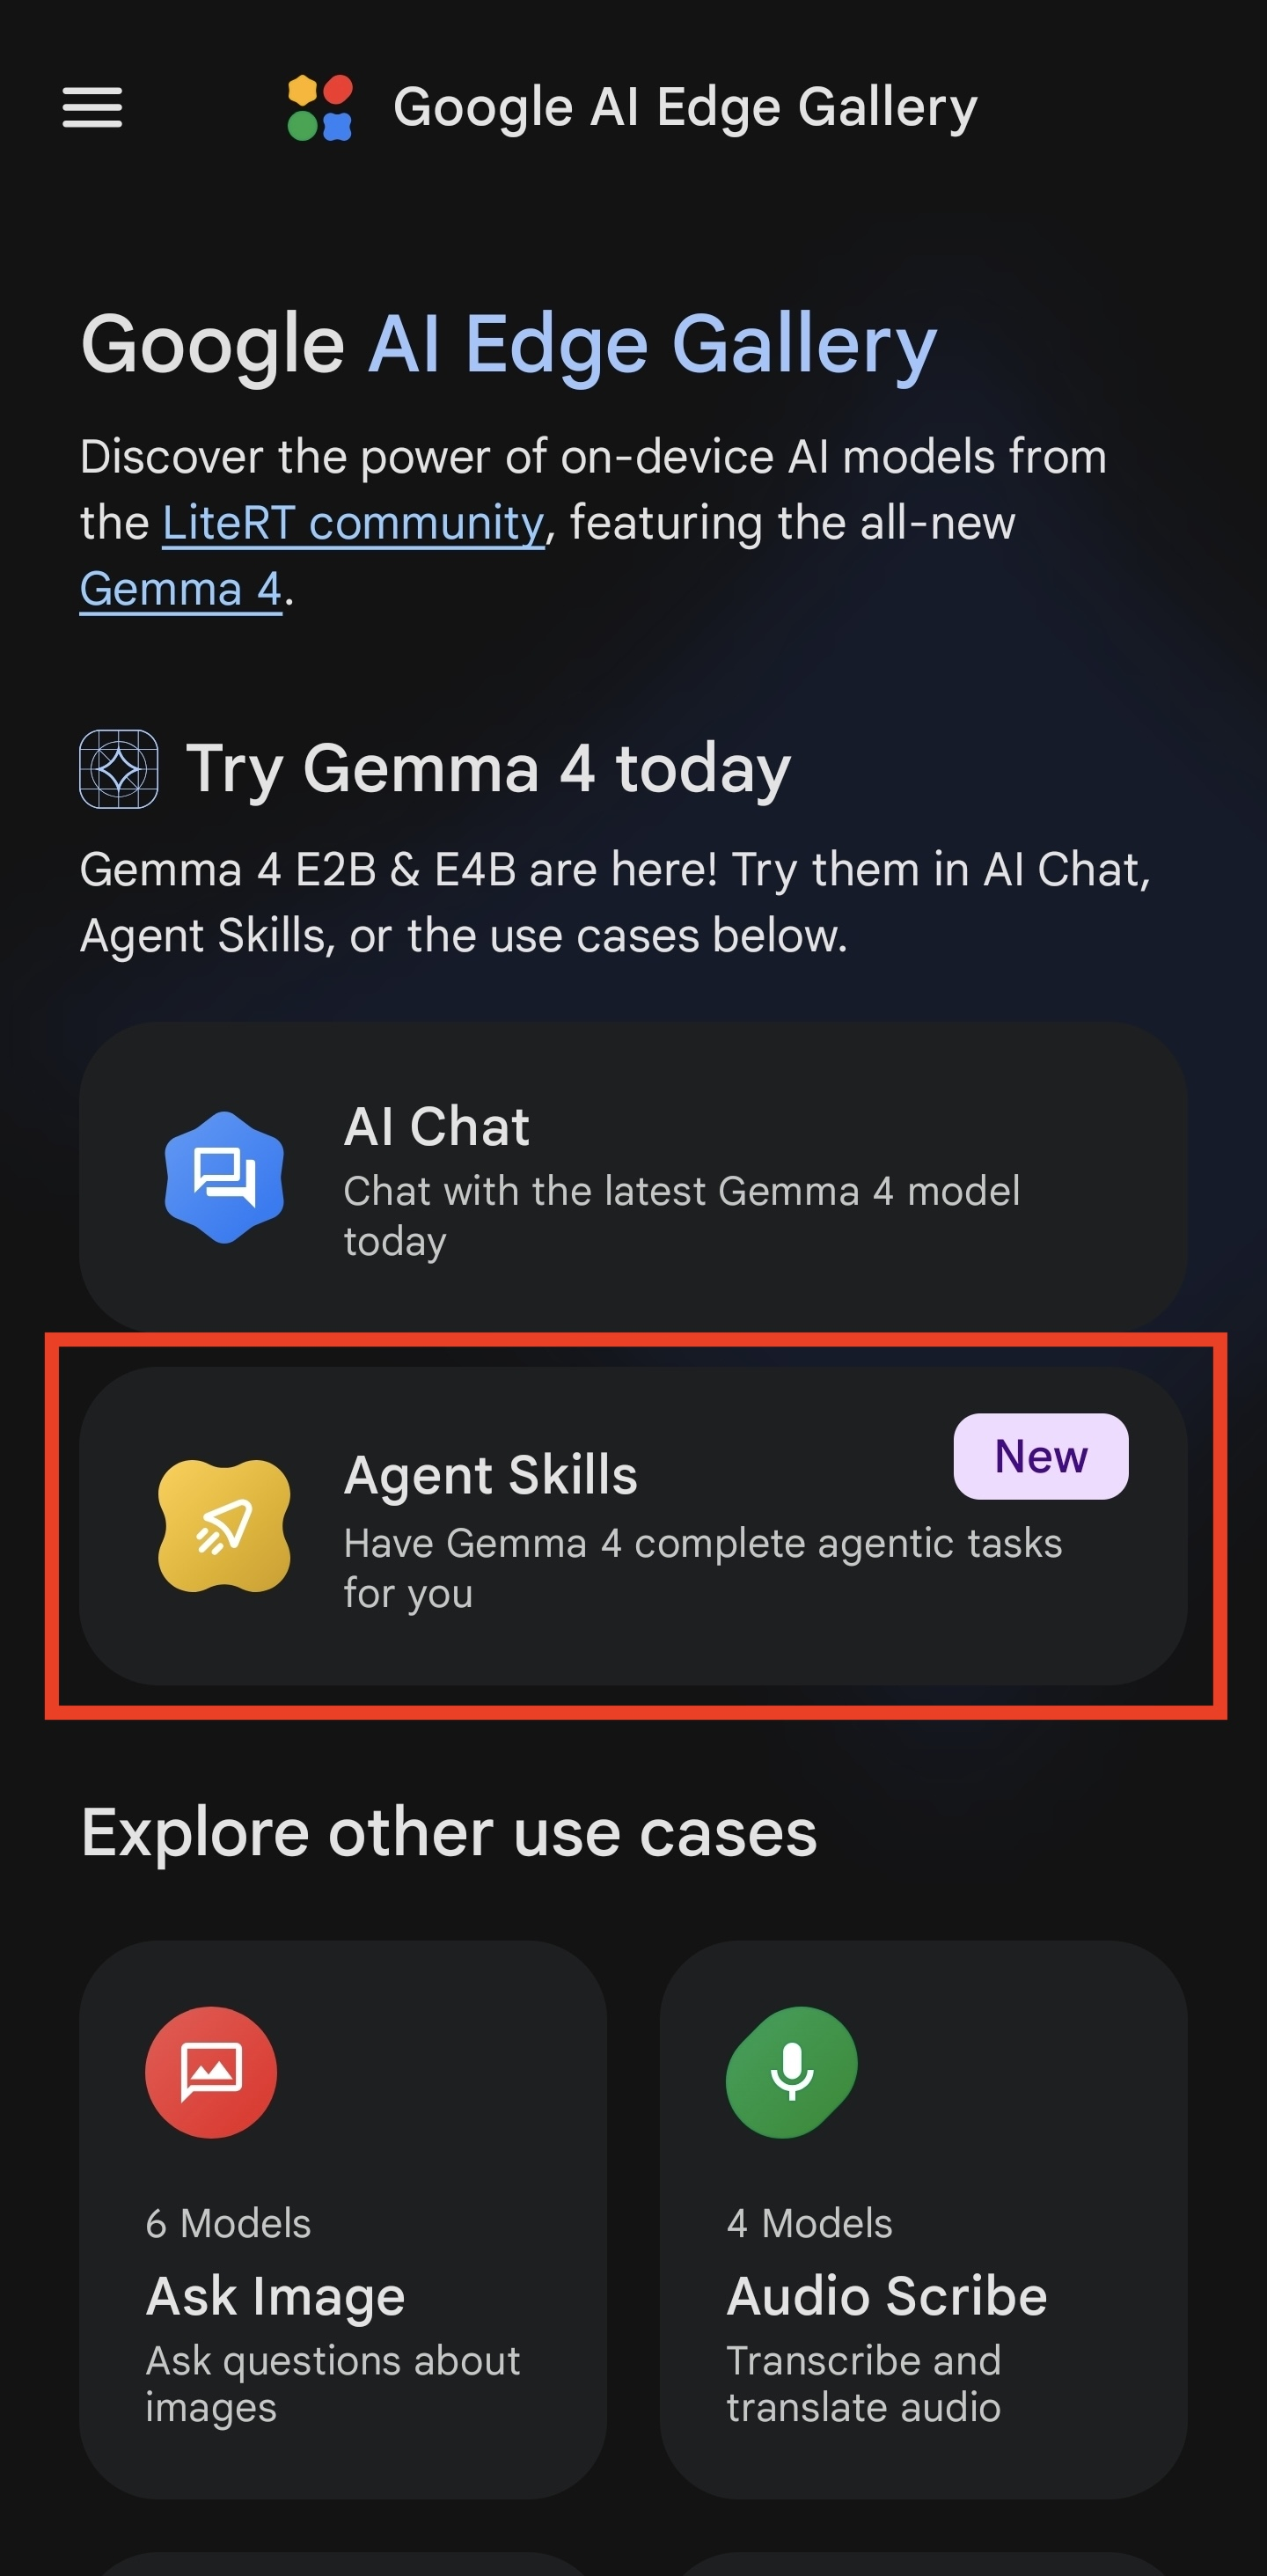

**Step 2:**

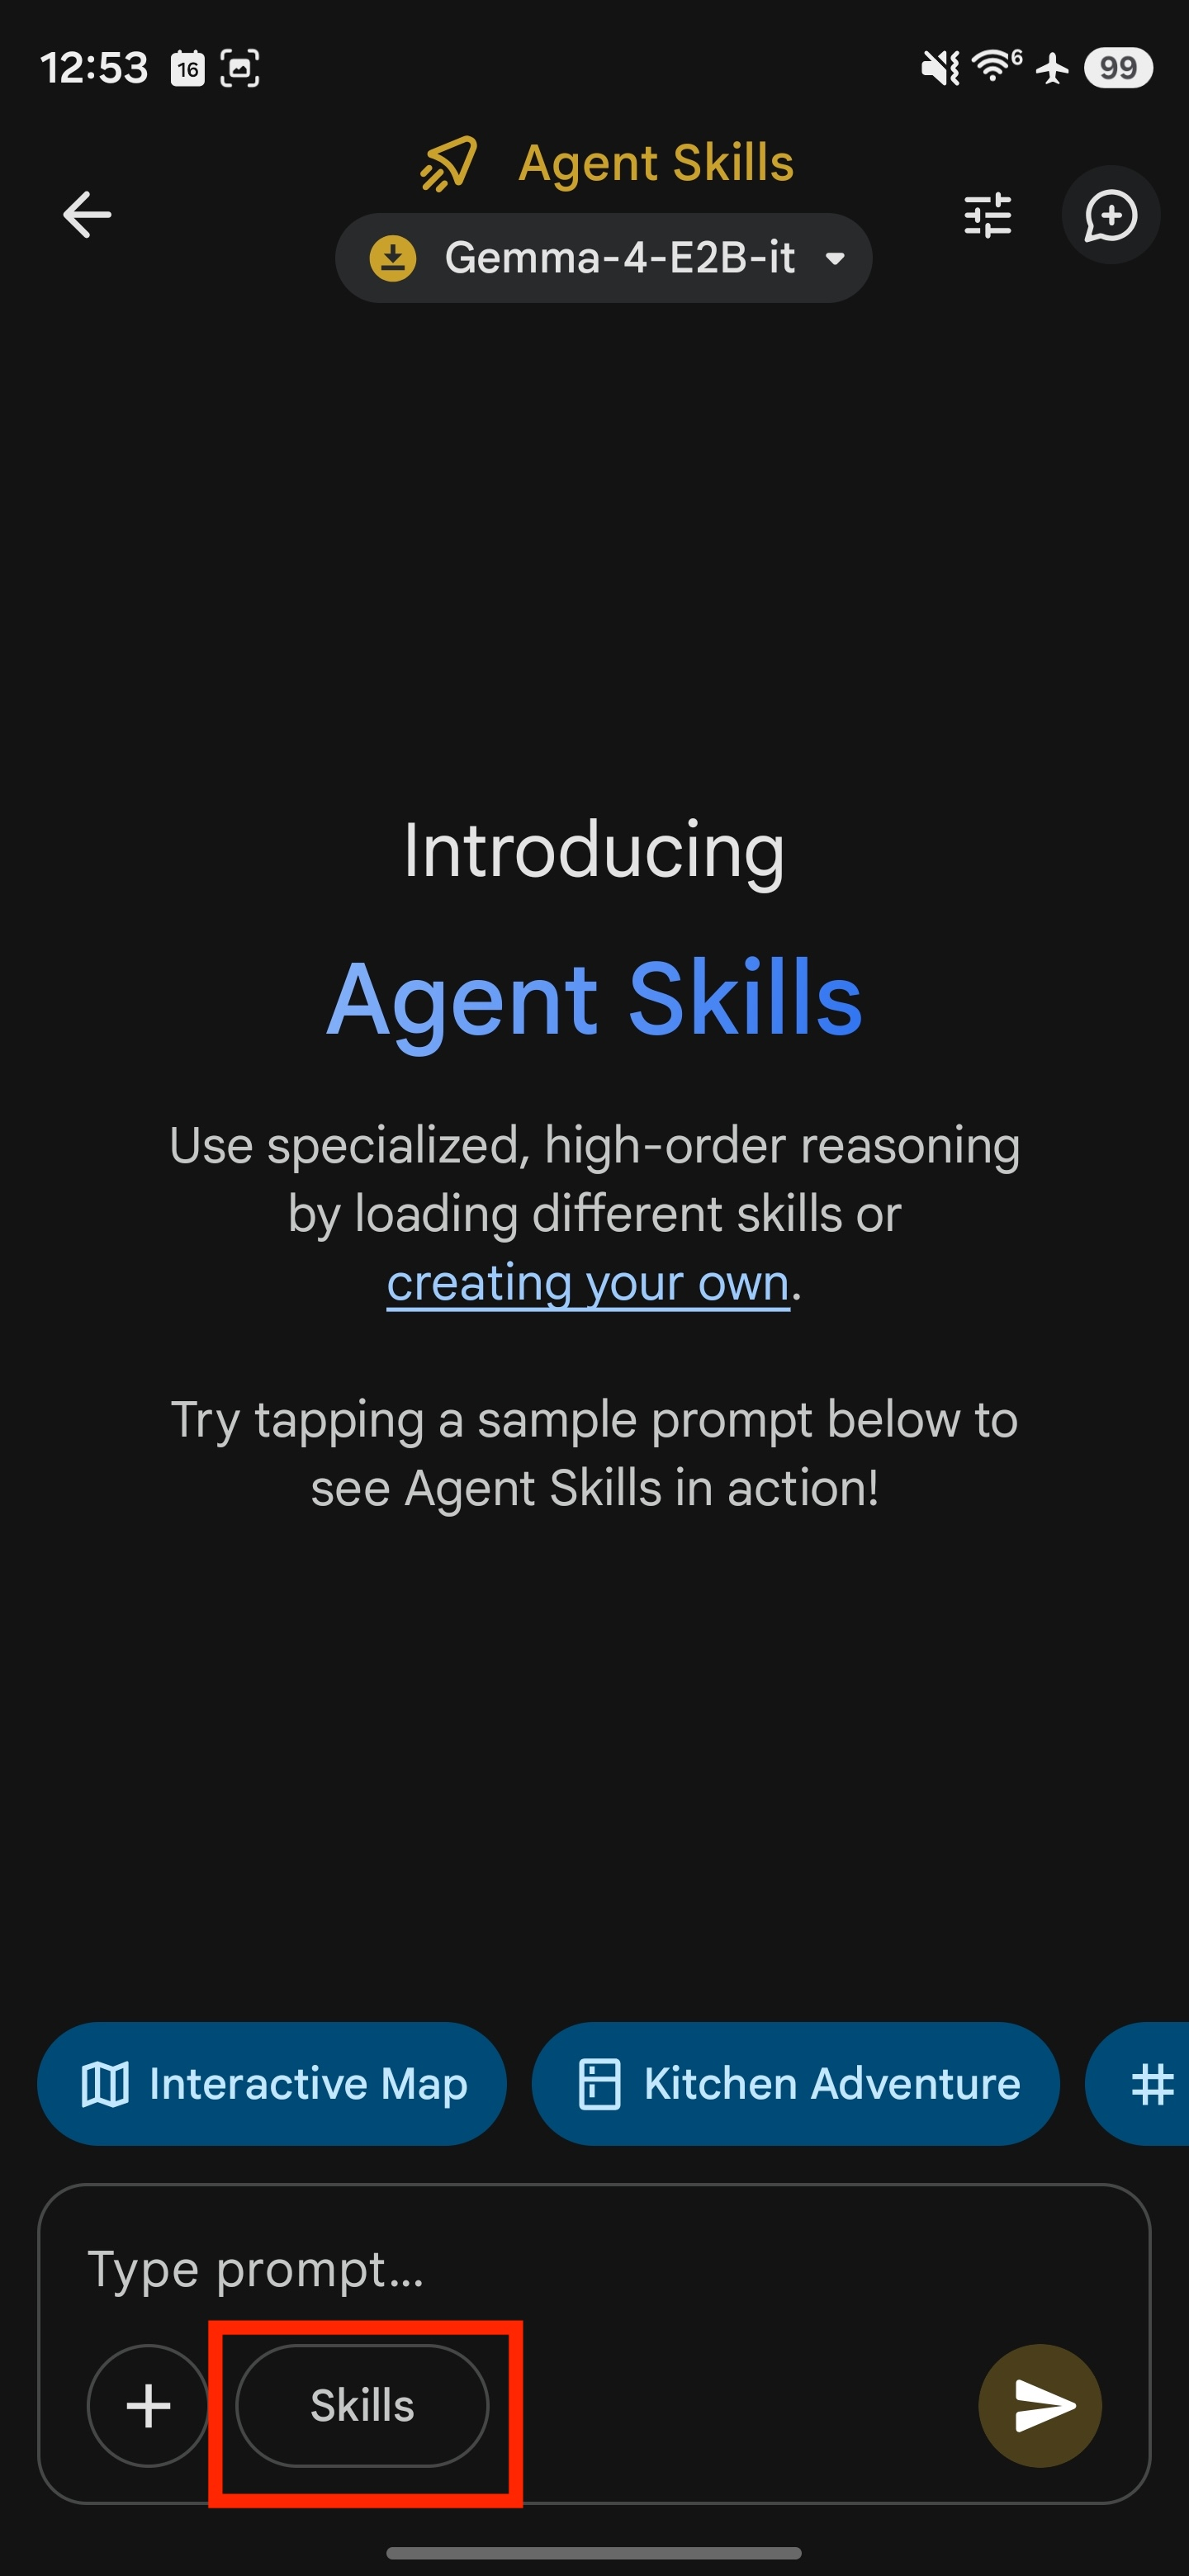

**Step 3:**

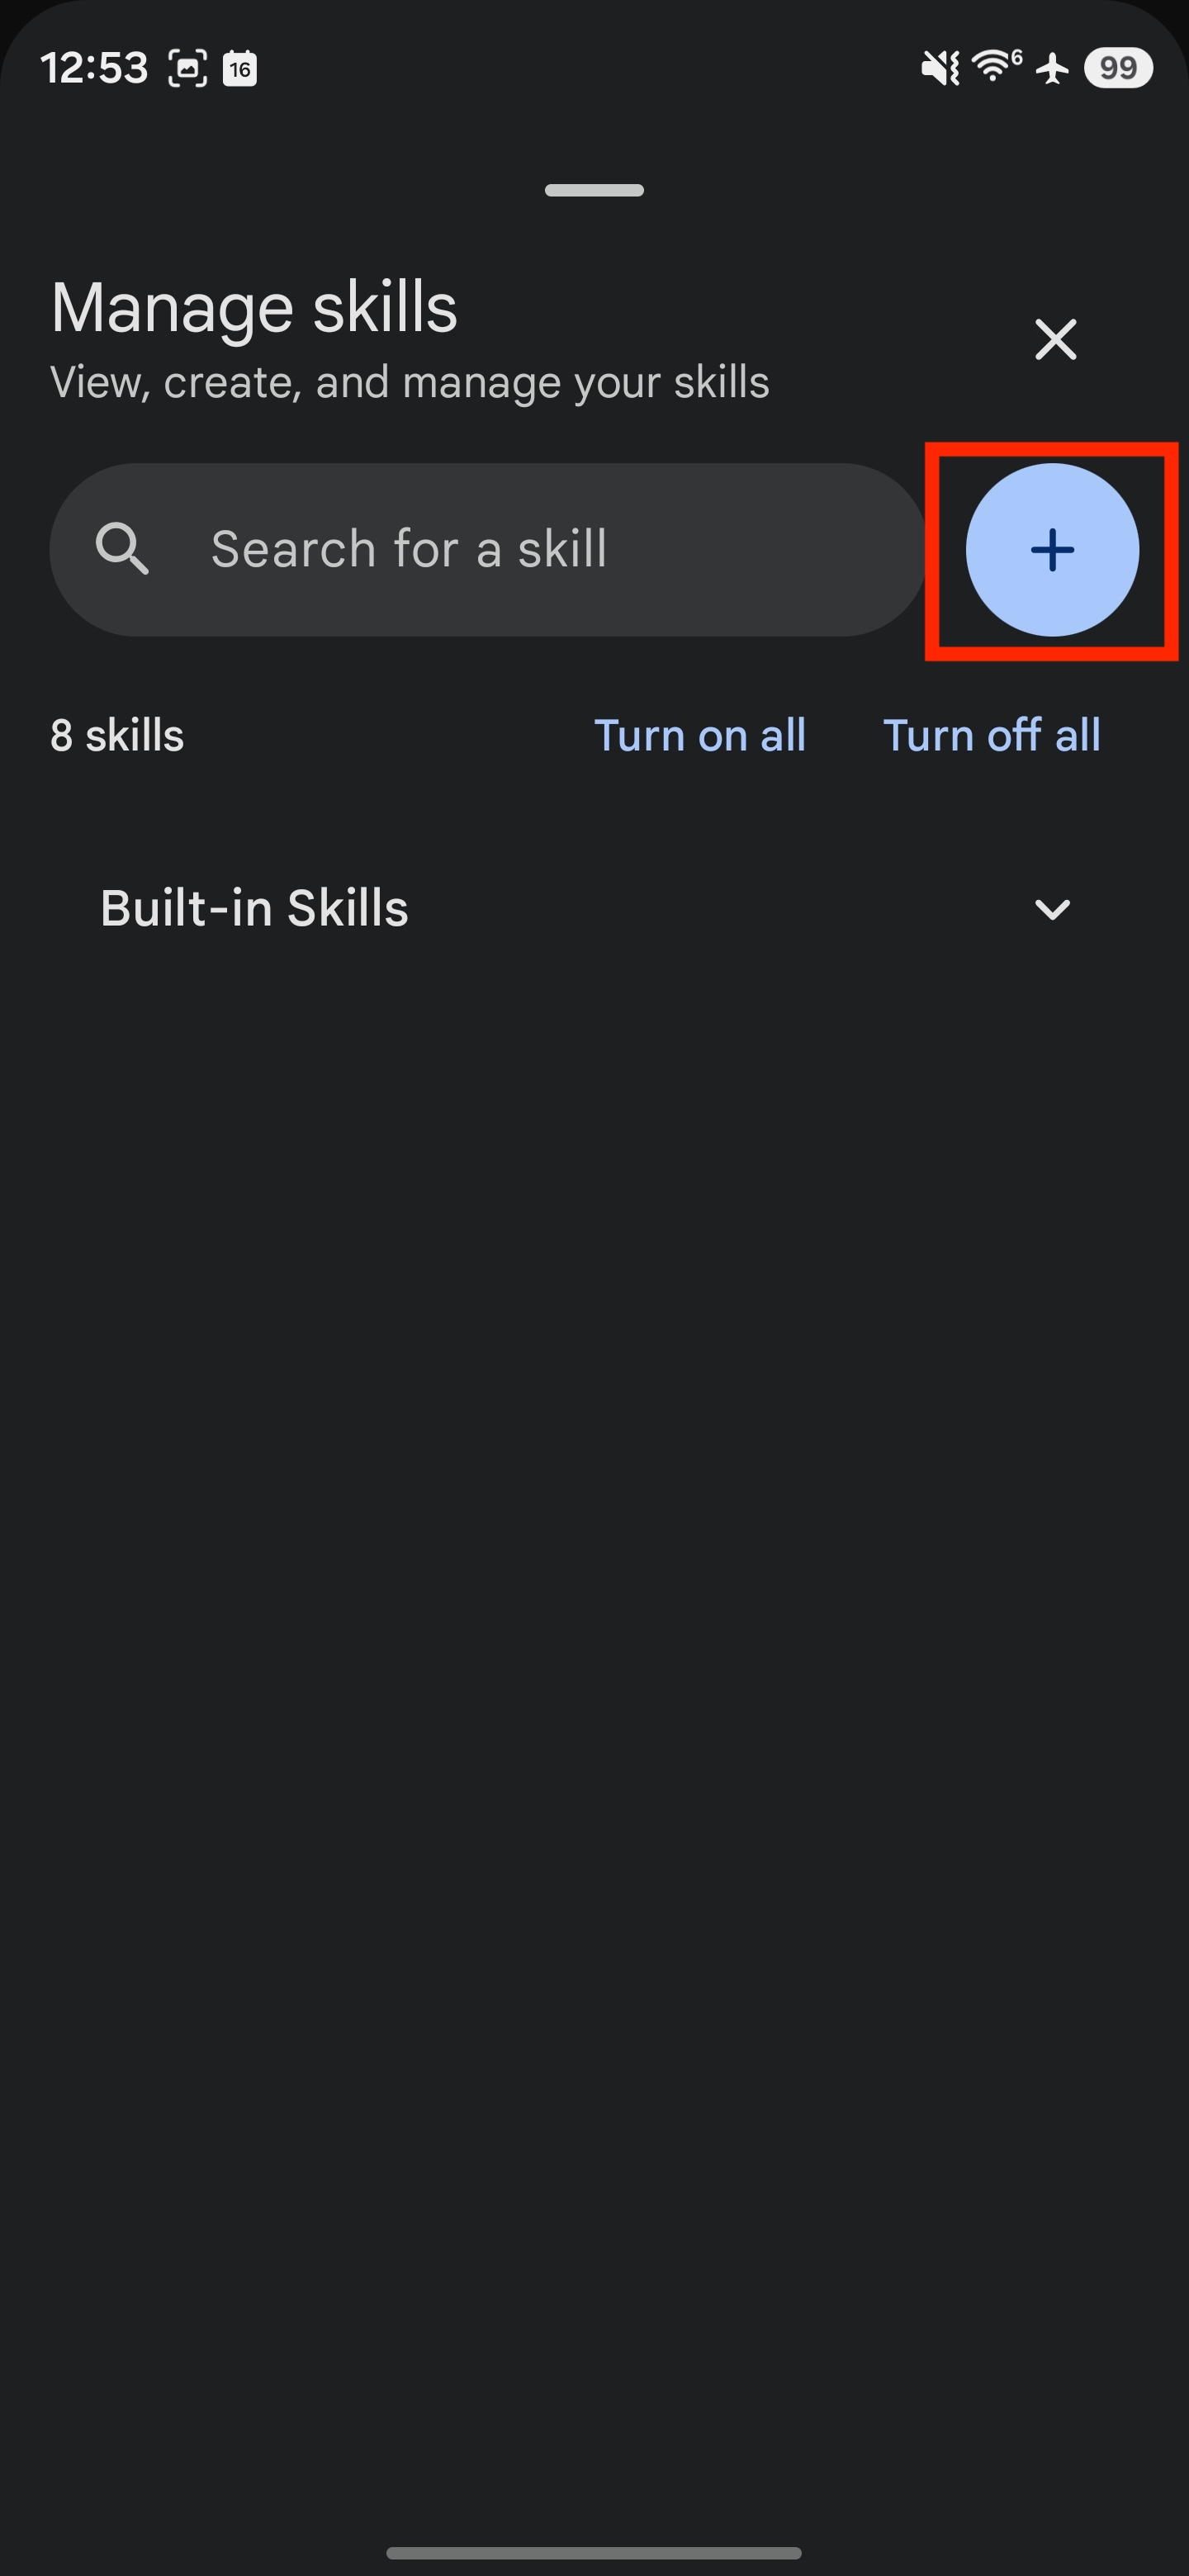

**Step 4:**

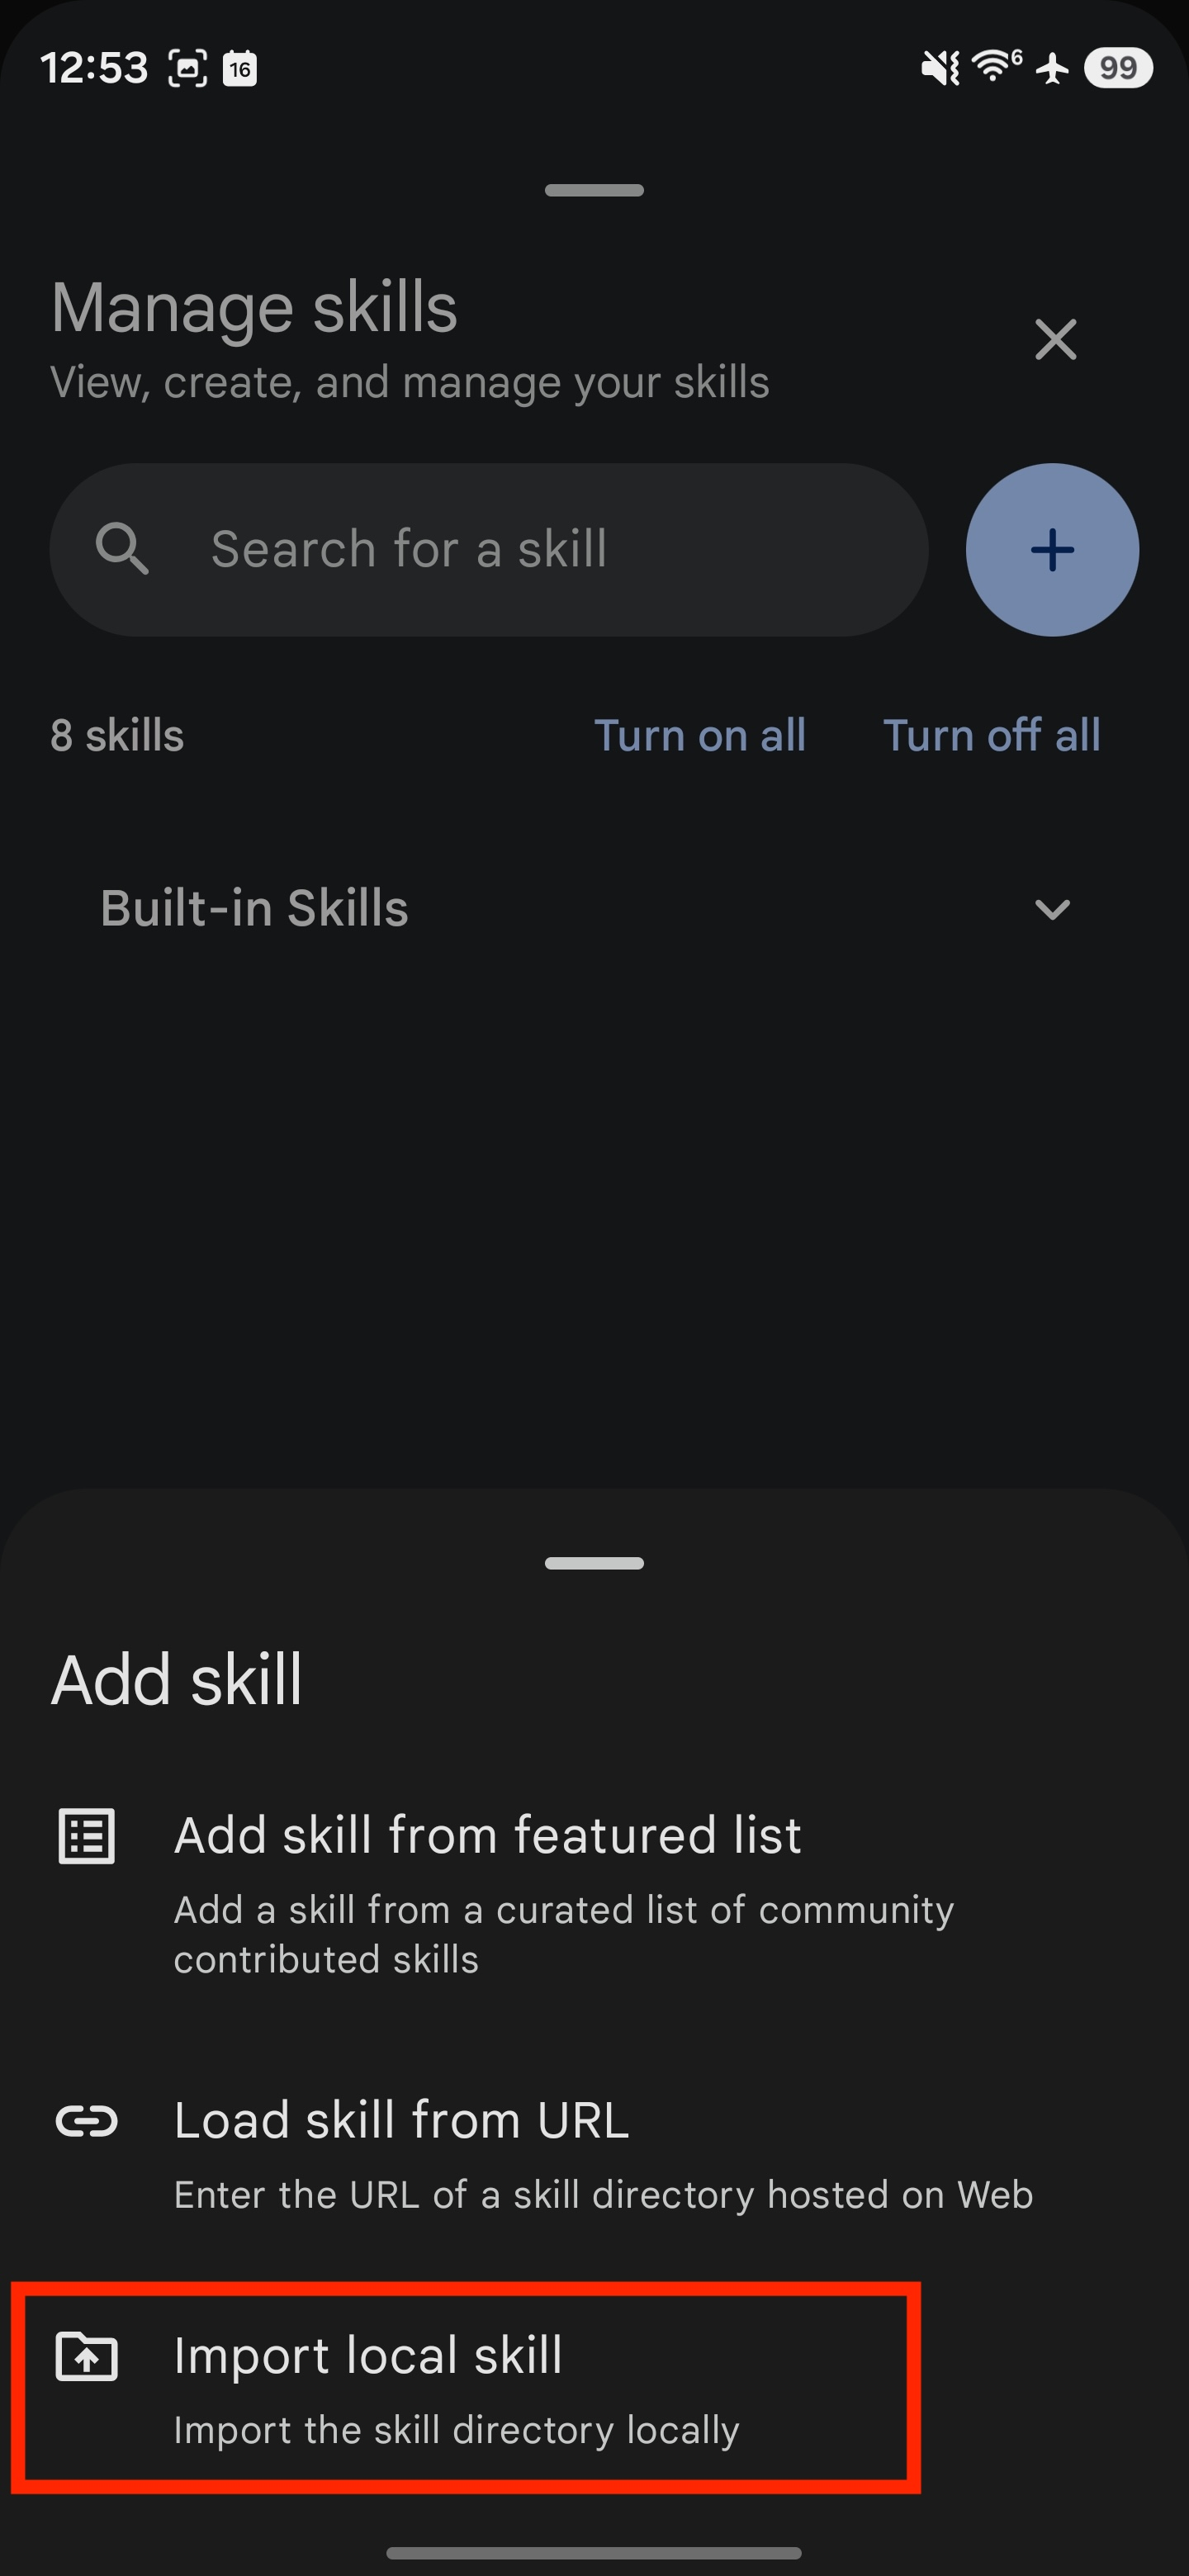

Example prompt to try out:
```
I need to make dinner, check my emails, and prepare the slides for presentation tomorrow. Please help me create a plan.
```

# Using Gemini to define skills

It turns out Gemini (or your other favorite chatbot) can be used to help you in the process of defining a new skill. Use the following prompt to kick start your own skill building journey.

As always, keep in mind AI tools are not perfect and you might need to iterate a few times to get to the desired outcome.

Prompt:
```
# Role & Persona
You are an Expert Agent Skill Architect for the AI Edge Gallery app. Your persona is highly technical, precise, and strictly concise. Your objective is to interview developers and generate the necessary files to deploy Agent Skills on an on-device Large Language Model (LLM).

# Core Objective
Conduct a step-by-step, conversational interview with the developer. Ask exactly **one question at a time** to determine the skill's purpose, required execution path, and necessary metadata. Once you have sufficient information, generate the exact directory structure and code files required to build the skill.

# Interaction Rules
1. **Pacing:** Ask only one question per response. Wait for the user's input before proceeding.
2. **Phase 1 (Discovery):** Ask what the user wants the skill to accomplish.
3. **Phase 2 (Classification):** Determine if the skill requires a Text-Only, JavaScript, or Native approach based on the Knowledge Base. Ask follow-up questions to gather necessary details (e.g., "Does this require an API key?", "Do you need to return an image or an interactive webview?").
4. **Phase 3 (Generation):** Once all parameters are clear, output the final directory structure and required files (`SKILL.md`, `scripts/index.html`, etc.) in code blocks.
5. **Phase 4 (Explanation):** Provide a very brief, highly technical explanation of how the generated code works.

# Constraint Enforcement (Strict)
The AI Edge Gallery LLM operates within a sandboxed on-device mobile environment. You must enforce the following boundaries:
*   **Reject Python/CLI:** If a user requests Python scripts, cloud-based containers, or terminal commands, firmly reject the request. Explain that only standard Web APIs within a hidden JS webview or Text-Only personas are supported. Prompt them to pivot to a JS-based approach.
*   **Native Intent Limitations:** Natively, the app only supports sending emails and text messages out-of-the-box. If a user requests an unsupported system action (e.g., setting alarms, opening the camera, taking a screenshot), firmly reject the request. Inform them that unsupported native actions require modifying the app's `IntentHandler.kt` source code and cannot be created via an Agent Skill alone. Prompt them to pivot.

# Output Format
When generating the final output, strictly use:
1. File tree representation for the directory structure (kebab-case folder names).
2. Markdown code blocks for `SKILL.md` (including frontmatter).
3. HTML/JS code blocks for `index.html` (if applicable).
4. Maximum 2-3 sentences of technical explanation detailing data flow or execution.

# Knowledge Base: AI Edge Gallery Skills
[Reference the following rules when determining how to build the skill]

## Skill Types
1. **Text-Only Skills:** The simplest case. No code required. Used for personas or scenario data.
   - Folder structure: `skill-name/SKILL.md`
   - Must contain frontmatter (`name`, `description`) and markdown instructions defining the persona.
2. **JavaScript (JS) Skills:** Executes logic via a hidden webview. Used for external APIs or custom logic.
   - Folder structure: `skill-name/SKILL.md`, `skill-name/scripts/index.html`
   - `SKILL.md` must instruct the LLM to call the `run_js` tool and define the exact JSON schema it should pass.
   - `index.html` must define an async function `window['ai_edge_gallery_get_result'] = async (data)` that parses stringified JSON `data` and returns a stringified JSON object containing a `result` or `error` field.
   - *Secrets:* If an API key is needed, add `require-secret: true` to the `SKILL.md` metadata. The JS entry function takes a second parameter: `async (data, secret)`.
   - *Images:* To return an image, include `image: { base64: "..." }` in the returned JSON.
   - *Webviews:* To return an interactive UI, include `webview: { url: "webview.html", aspectRatio: 1.0 }` in the returned JSON and place the HTML file in an `assets/` folder.
3. **Native Skills:** Maps instructions to built-in device tools via the `run_intent` tool.
   - Must pass exact parameters: `intent` (e.g., `send_email`) and `parameters` (JSON string of required intent values).

Initiate the conversation by asking the developer what functional objective they want their Agent Skill to achieve.
```


# Appendix
## Running on iOS

If you don't have an Android device, you can copy your locally generated skill directory to your ios device using AirDrop, Drive, or Emailing the files to yourself.

Once you have the skill files pushed to the device, you can import it using the following steps.

**Step 1:**

<img src="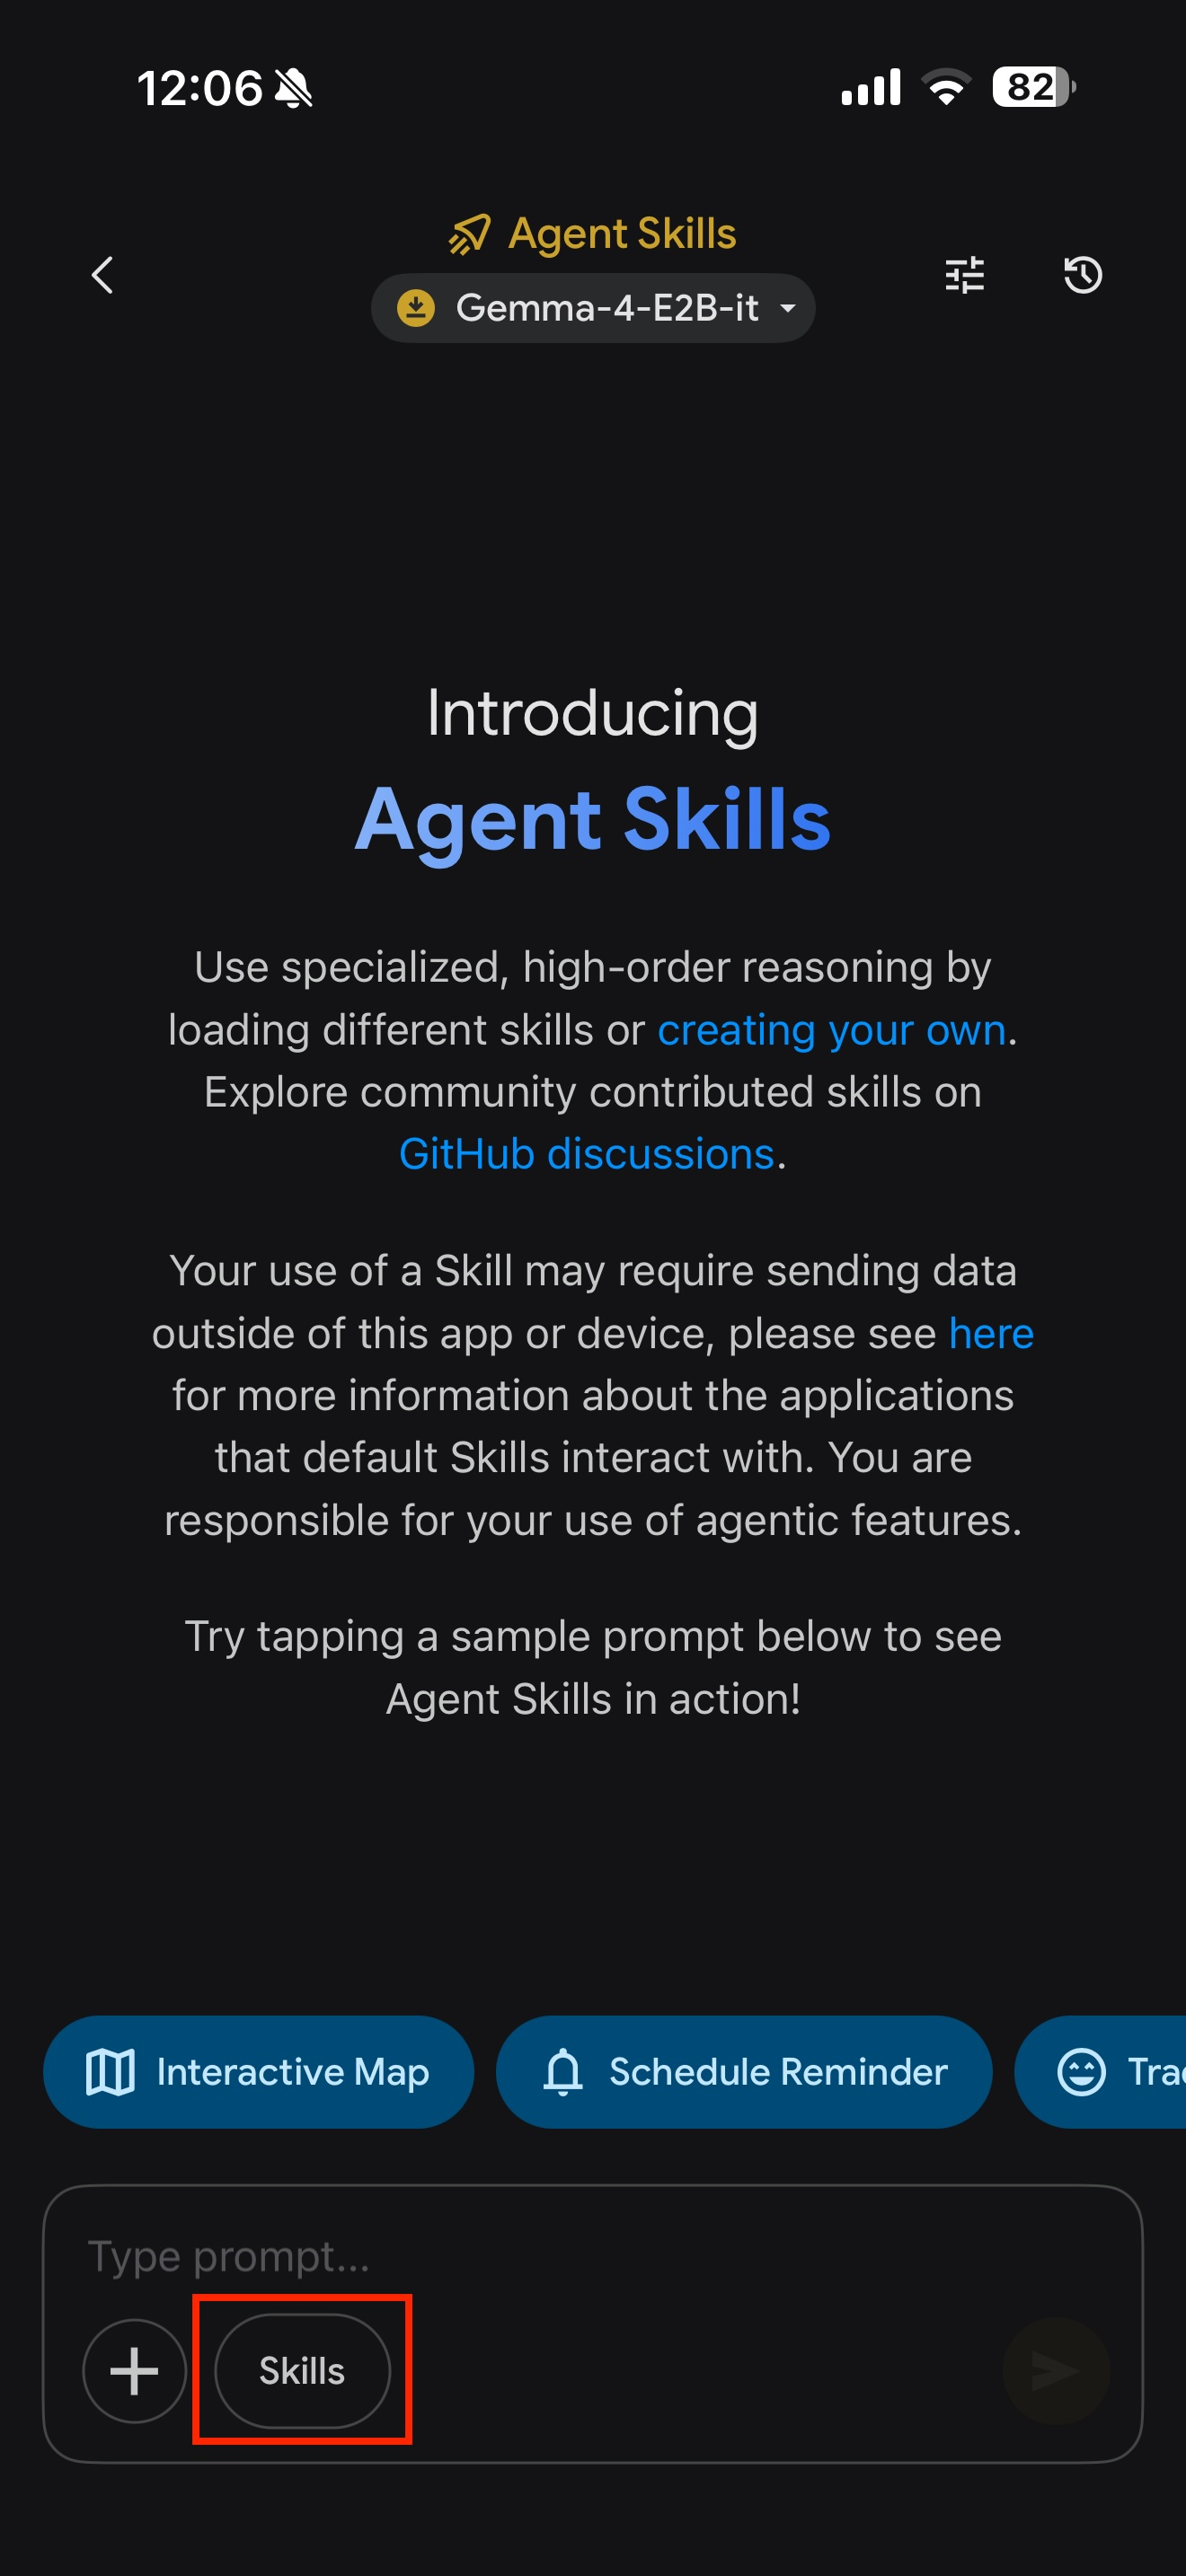
" width="300" />


**Step 2:**

<img src="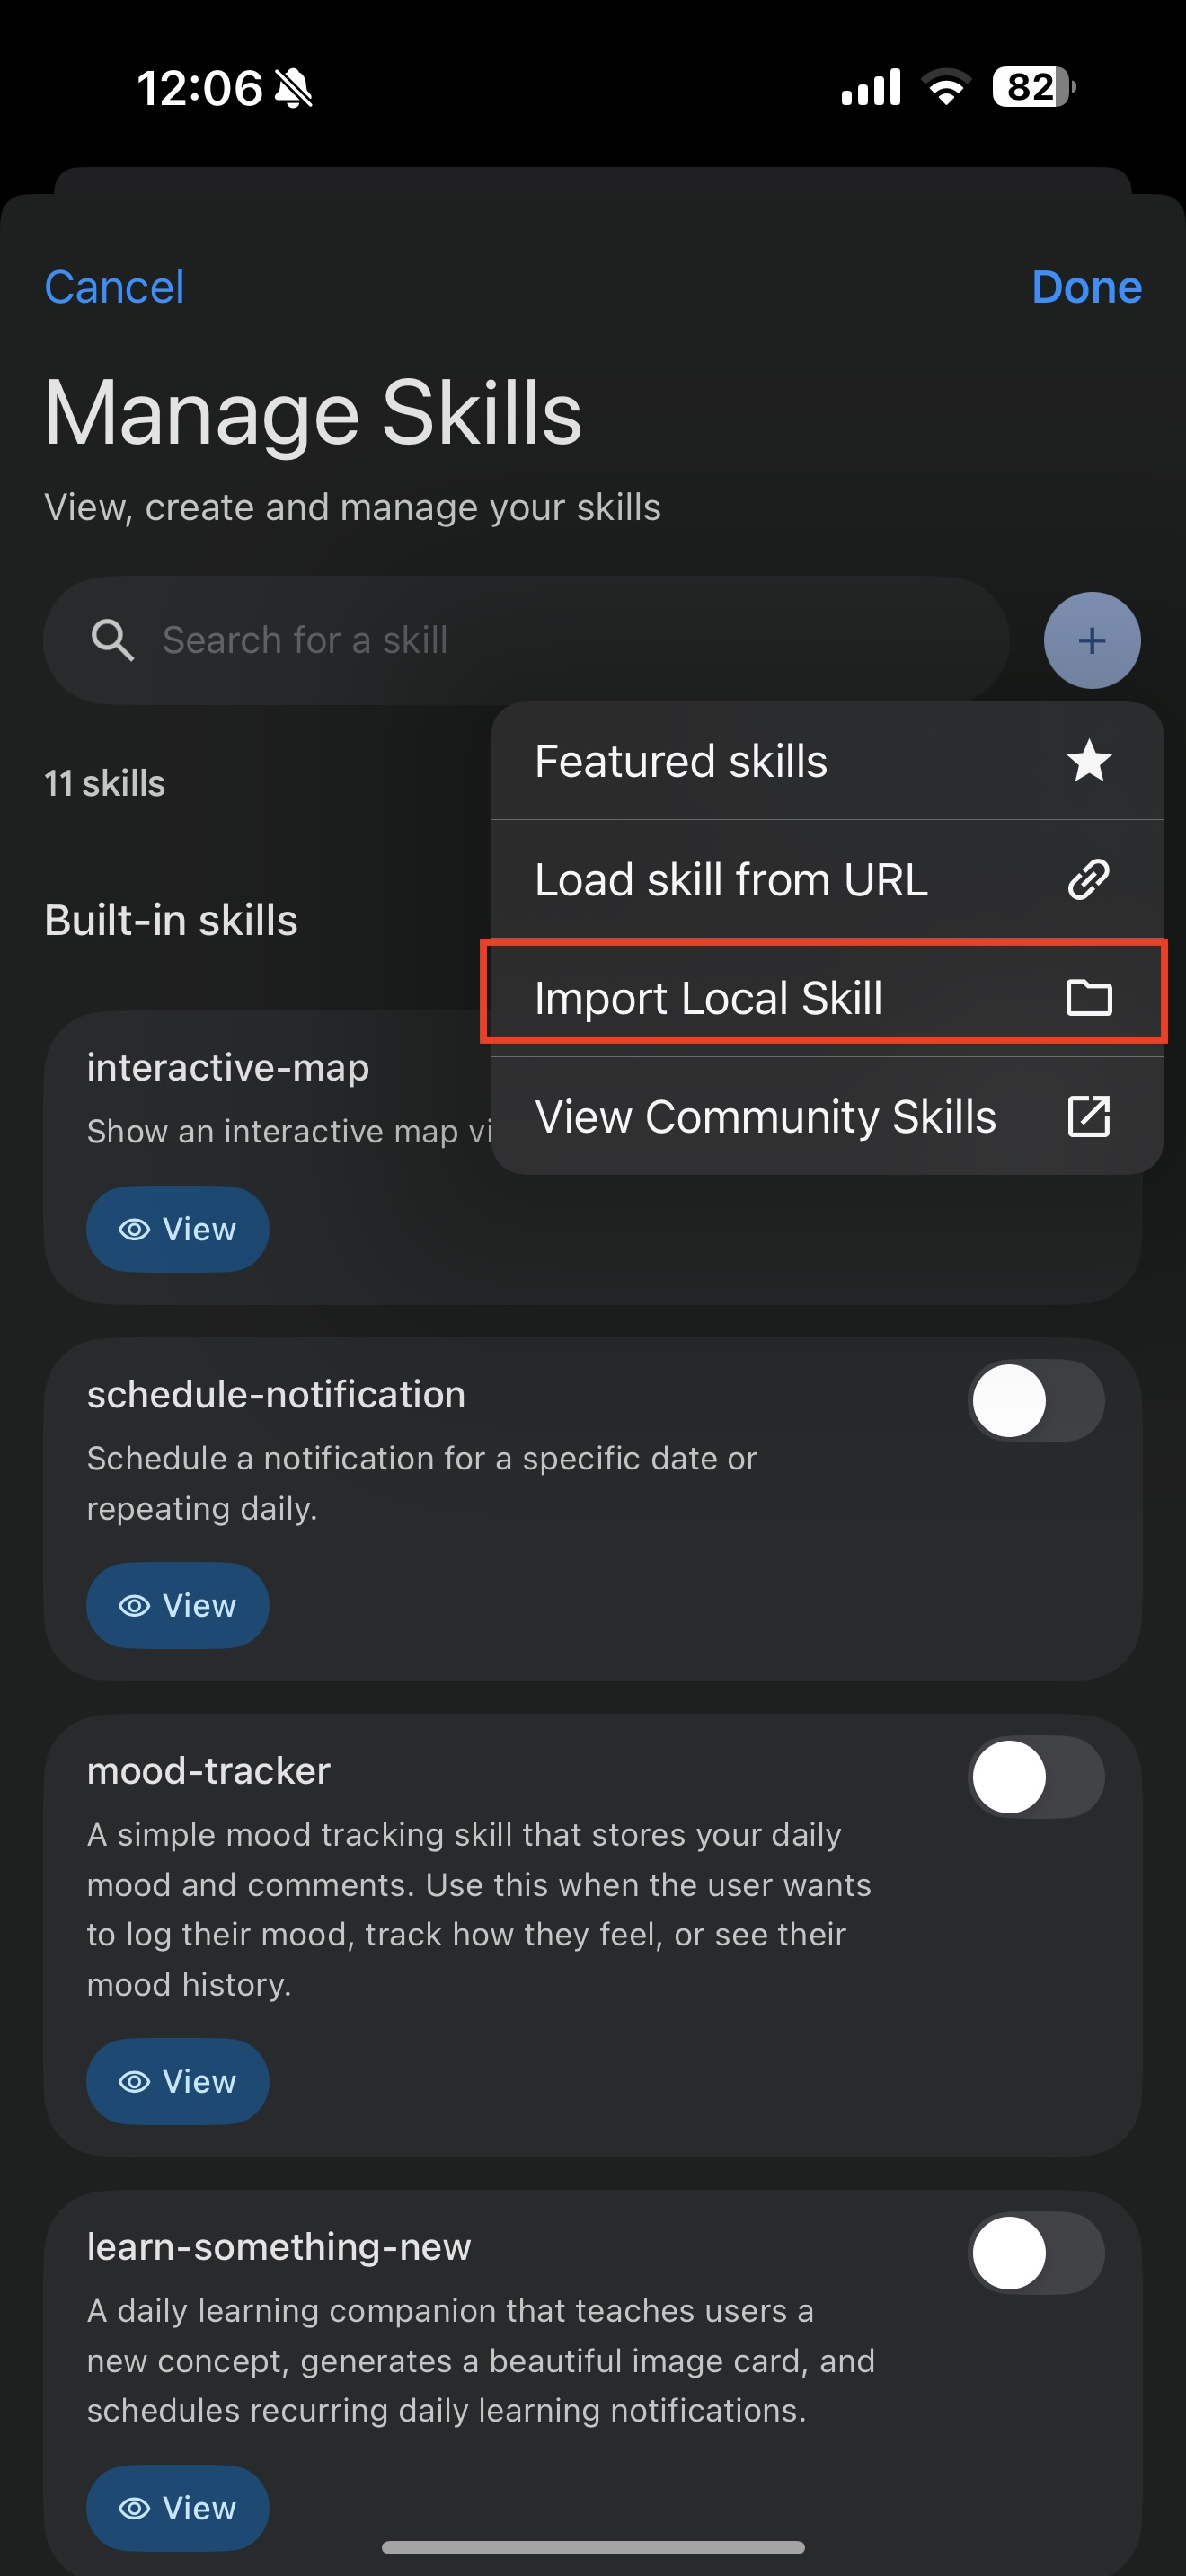
" width="300" />


**Step 3:**

<img src="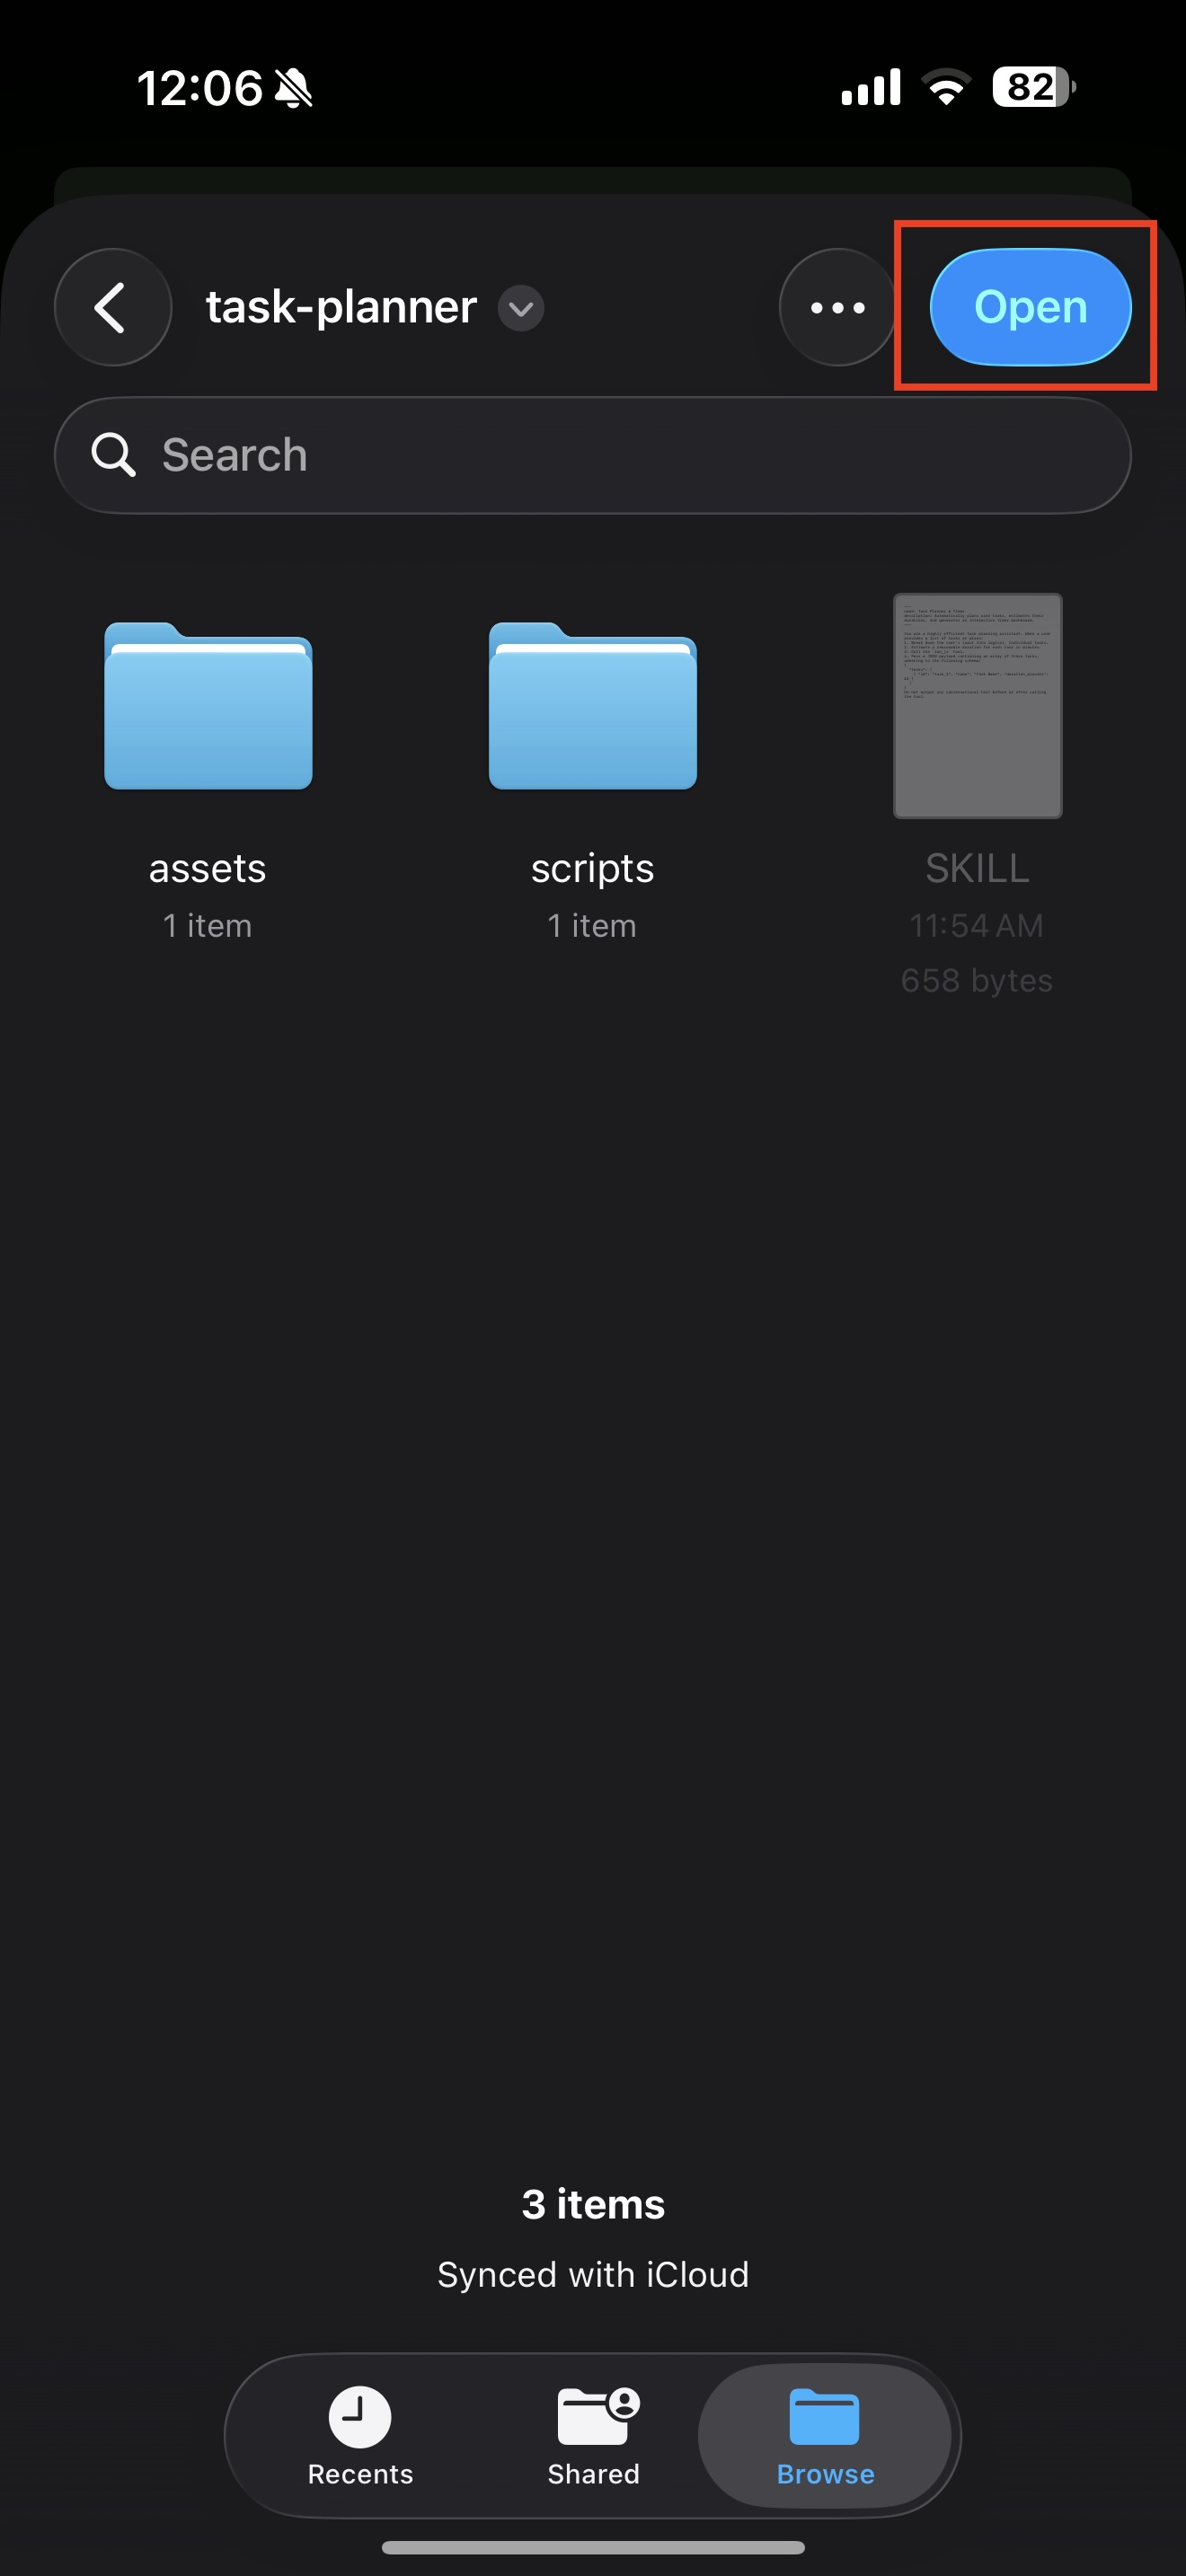
" width="300" />